# Müşteri Ayrılma Tahmini ile Temel Makine Öğrenmesi Akışı: 
Amaç:
* Müşteri ayrılma (churn) tahmini senaryosu için gerçekçi (kirli) bir veri seti simülasyonu yapmak.
* Bu kapsamda sentetik veriye bilinçli olarak eksik değer (NaN) ve aykırı değerler (gürültü) eklenmiştir.
 İş akışında eksik değerlerin tespiti/doldurulması, veri ön işleme, 
 modellerin eğitilmesi, ve test kümesi performans değerlendirmesi yapılır.

Adımlar:
### Sentetik Veri Seti Oluşturma
*  1. Gerekli kütüphanelerin içeriye aktarılması
*  2. Veri setinin hazırlanması  
*  3. Veri setine eksik değer (NaN) ve outlier ekleme
*  4. Veri setine hatalı veri ekleme 
*  5. Veri setini csv dosyası olarak kaydedilmesi
### Veri Setinin Düzenlenmesi ve Keşifsel Veri Analizi (EDA)     
*   6. Veri setinin içeriye aktarılması
*   7. Veri setinin ilk 4 ve rastgele 7 satırının incelenmesi
*   8. Veri setinin boyutunun ve sütun isimlerinin kontrol edilmesi
*   9. Veri setinin genel bilgisinin ve veri tiplerinin kontrol edilmesi
*   10. Tekrar eden (mükerrer) kayıtların tespit edilmesi
*   11. Eksik değerlerin (NaN) kontrol edilmesi
*   12. Özet istatistiklerin görüntülenmesi
*   13. Veri setindeki özelliklerin sayısal ve kategorik olarak ayrılması
*   14. Aykırı ve tutarsız değerlerin incelenmesi
*   15. Sütunlardaki benzersiz (unique) değer yapılarının incelenmesi
*   16. Kategorik değişkenlerin sınıf dağılımlarının incelenmesi
*   17. Hem sayısal hem de kategorik değişkenlerin genel dağılımlarının grafikle incelenmesi
*   18. Korelasyon analizi ile değişkenler arasındaki ilişkilerin incelenmesi
### Makine Öğrenmesi Modelleri
*   19. Bağımlı ve bağımsız değişkenlerin tanımlanması, train/test olarak ayrılması
*   20. Kategorik değişkenlere uygun encoding yöntemlerinin uygulanması
*   21. Değişkenlerin ölçeklendirilmesi (StandardScaler)
*   22. Tüm Modellerin For Döngüsü ile Eğitilmesi ve Karşılaştırılması
*   23. GridSearchCV ile Hiperparametre Optimizasyonu

Kullanılan Kütüphaneler:
- pandas, numpy, matplotlib, scikit-learn

In [1]:
# 1. Gerekli kütüphanelerin içeriye aktarılması

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler



from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.model_selection import GridSearchCV

In [2]:
# 2. Veri setinin hazırlanması
np.random.seed(42)     # üretilecek rastgele sayı dizisini sabit ve tekrarlanabilir kılmak için kullanılan bir başlangıç değeridir.
n_rows = 250            # veri setinin satır sayısı

# features 
dogum_yili = np.random.randint(1961, 2026, size=n_rows)
gelir = np.random.randint(30000, 150000, size=n_rows)
abonelik_suresi = np.random.randint(1, 60, size=n_rows)
destek_talebi_sayisi = np.random.randint(1, 10, size=n_rows)

sehirler = ['İstanbul', 'Ankara', 'İzmir', 'Bursa', 'Antalya', 'Konya', "istanbul ", "bursa", " kocaeli"]
sehir = np.random.choice(sehirler, size=n_rows)

uyelik_tipleri = ["Standart", "Premium", "Platin", "standard ", " Premium"]
uyelik_tipi = np.random.choice(uyelik_tipleri, size=n_rows, p=[0.4, 0.25, 0.15, 0.1, 0.1])

# target
x1 = destek_talebi_sayisi
x2 = abonelik_suresi / 10.0
x3 = gelir / 50000.0

churn_olasigi = (
    2.5                             # Başlangıç sabit değeri (Bias)
    + 1.8 * x1                      # Destek talebinin doğrusal pozitif etkisi
    - 1.2 * x2                      # Abonelik süresinin doğrusal negatif etkisi
    + 0.15 * (x1 ** 2)              # Destek talebinin karesel (artan) etkisi
    + 0.3 * x1 * (6.0 - x2)         # Destek talebi ve abonelik süresi etkileşimi
    + np.random.normal(0, 1.5, n_rows) # Rastgele gürültü / Varyans (Noise)
)


churn = (churn_olasigi > np.median(churn_olasigi)).astype(int)

df = pd.DataFrame({
    'dogum yili': dogum_yili,
    'gelir': gelir,
    'abonelik suresi': abonelik_suresi,
    'destek_talebi_Sayisi': destek_talebi_sayisi,
    'sehir': sehir,
    'uyelik_Tipi': uyelik_tipi,
    'churn': churn
})

In [3]:
# 3. Veri setine eksik ve aykırı değer ekleme

# destek_talebi_sayisi sütununa rastegele Eksik Değer (NaN) ekleme
df['destek_talebi_Sayisi'] = df['destek_talebi_Sayisi'].astype(str)
mask_nan = np.random.rand(n_rows) < 0.08  # %8 olasılık maskesi
df.loc[mask_nan, 'destek_talebi_Sayisi'] = np.nan

# gelir sütununa rastgele outlier ekleme
df['gelir'] = df['gelir'].astype(float) # İlerideki medyan dönüşümü için float yaptık
mask_outlier = np.random.rand(n_rows) < 0.01  
df.loc[mask_outlier, 'gelir'] = 999999

In [4]:
# 4.Veri setine hatalı veri ekleme
# Var olan ilk müşterinin (0.ıncı indeksteki müşteri) bilgilerini kopyalayalım
hatali_veri = df.iloc[[0]].copy()

# Bu kopya müşterinin gelirini imkansız bir rakam olan negatif değer yapalım
hatali_veri['gelir'] = -45000.00

# Bu hatalı satırı mevcut veri setimizin (df) en altına yapıştıralım
df = pd.concat([df, hatali_veri], ignore_index=True)

In [5]:
# 5.Veri setini csv dosyası olarak kaydedilmesi
df.to_csv('musteri_verisi.csv', index=False, encoding='utf-8')

### Veri Setini Tanıma

In [6]:
# 6. Veri setinin içeriye aktarılması (pd.read_csv)

df = pd.read_csv("musteri_verisi.csv")

In [7]:
# 7. Veri setinin ilk 4 ve rastgele 7 satırının incelenmesi (head ve sample)

df.head(4)    # ilk 4 veri

,dogum yili,gelir,abonelik suresi,destek_talebi_Sayisi,sehir,uyelik_Tipi,churn
0,2012,66212.0,10,5.0,kocaeli,Standart,1
1,1975,73525.0,26,7.0,Antalya,Standart,1
2,2021,77202.0,34,8.0,İzmir,Premium,1
3,1981,62635.0,51,1.0,Antalya,Standart,0


In [8]:
df.sample(7)

,dogum yili,gelir,abonelik suresi,destek_talebi_Sayisi,sehir,uyelik_Tipi,churn
17,1982,145668.0,57,5.0,İstanbul,Standart,0
132,2022,35949.0,4,3.0,İstanbul,Standart,1
95,1995,122772.0,29,4.0,Antalya,Standart,0
9,1990,30301.0,50,9.0,kocaeli,Standart,1
221,1968,65195.0,37,8.0,istanbul,Standart,1
240,2008,42161.0,51,5.0,kocaeli,Premium,0
128,2022,55945.0,17,7.0,Konya,Premium,1


In [9]:
# 8. Veri setinin boyutunun ve sütun isimlerinin kontrol edilmesi (shape ve columns)

print(f"Satır sayısı: {df.shape[0]}")
print(f"\nSütun sayısı: {df.shape[1]}")
print(f"\nVeri setinin kolonları: {df.columns}")

Satır sayısı: 251

Sütun sayısı: 7

Veri setinin kolonları: Index(['dogum yili', 'gelir', 'abonelik suresi', 'destek_talebi_Sayisi',
       'sehir', 'uyelik_Tipi', 'churn'],
      dtype='object')


In [10]:
# NOT: Veri setindeki bazı kolon isimlerinde boşluk karakteri (örn: 'dogum yili') ve düzensiz büyük/küçük harf kullanımları (örn: 'destek_talebi_Sayisi') mevcuttur. 
# Sütun isimlerinde boşluk olması, Python'da nesne yönelimli erişim (df.dogum_yili) yaparken hata (SyntaxError) almamıza neden olur. 
# Bu nedenle, veri ön işleme aşamasında tüm sütun isimlerindeki boşlukları alt çizgi (_) ile değiştirmek ve harfleri tamamen küçük harfe (lowercase) senkronize etmek en doğru yaklaşımdır.

In [11]:
df.columns = df.columns.str.replace(" " , "_").str.lower()

In [12]:
df.columns

Index(['dogum_yili', 'gelir', 'abonelik_suresi', 'destek_talebi_sayisi',
       'sehir', 'uyelik_tipi', 'churn'],
      dtype='object')

In [13]:
# 9. Veri setinin genel bilgisinin ve veri tiplerinin kontrol edilmesi (info ve dtypes)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   dogum_yili            251 non-null    int64  
 1   gelir                 251 non-null    float64
 2   abonelik_suresi       251 non-null    int64  
 3   destek_talebi_sayisi  232 non-null    float64
 4   sehir                 251 non-null    object 
 5   uyelik_tipi           251 non-null    object 
 6   churn                 251 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 13.9+ KB


In [14]:
df.dtypes

dogum_yili                int64
gelir                   float64
abonelik_suresi           int64
destek_talebi_sayisi    float64
sehir                    object
uyelik_tipi              object
churn                     int64
dtype: object

In [15]:
# 10. Tekrar eden (mükerrer) kayıtların tespit edilmesi

df.duplicated().sum()

np.int64(0)

In [16]:
# 11. Eksik değerlerin (NaN) kontrol edilmesi
df.isnull().sum()

dogum_yili               0
gelir                    0
abonelik_suresi          0
destek_talebi_sayisi    19
sehir                    0
uyelik_tipi              0
churn                    0
dtype: int64

In [17]:
# Eksik değerlerin oranını hesaplama
eksik_oranı = (df["destek_talebi_sayisi"].isnull().mean() * 100).round(2)

print(f"Destek Talebi Sayısı sütunundaki eksik veri oranı: %{eksik_oranı}")

Destek Talebi Sayısı sütunundaki eksik veri oranı: %7.57


In [18]:
# Eksik verilere sahip satırların Churn sınıflarına göre dağılımını inceleyelim
eksik_grup = df[df["destek_talebi_sayisi"].isnull()]
print("--- EKSİK VERİLERİN CHURN SINIFLARINA DAĞILIMI (ADET) ---")
print(eksik_grup["churn"].value_counts(dropna=False))

print("\n--- EKSİK VERİLERİN CHURN SINIFLARINA DAĞILIMI (YÜZDE) ---")
print((eksik_grup["churn"].value_counts(normalize=True) * 100).round(2))


--- EKSİK VERİLERİN CHURN SINIFLARINA DAĞILIMI (ADET) ---
churn
1    10
0     9
Name: count, dtype: int64

--- EKSİK VERİLERİN CHURN SINIFLARINA DAĞILIMI (YÜZDE) ---
churn
1    52.63
0    47.37
Name: proportion, dtype: float64


In [19]:
# Eksik Veri Değerlendirme ve Aksiyon Notu:

# Dağılım Analizi: Yapılan incelemede, destek talebi verisi eksik olan müşterilerin Churn sınıflarına neredeyse yarı yarıya (%52.63 ve %47.37) tamamen dengeli dağıldığı görülmüştür. Veride belirli bir sınıfa (0 veya 1) yönelik  bir yığılma veya yanlılık söz konusu değildir.
# Satır Silme (Listwise Deletion) Yaklaşımı: Sınıf dağılımı dengeli olduğu için bu satırların silinmesi hedef değişkenin oranını bozmayacaktır. Ancak 251 satırlık görece küçük bir veri setinde %7.57'lik (~19 satır) bir veri kaybı yaşanması, modelin genel performansını olumsuz etkileyebilecek bir bilgi kaybı (Data Loss) riski taşımaktadır.

In [20]:
print(f"Destek Talep Sayısı Mean: {df['destek_talebi_sayisi'].mean()}")
print(f"Destek Talep Sayısı Median: {df['destek_talebi_sayisi'].median()}")

Destek Talep Sayısı Mean: 4.780172413793103
Destek Talep Sayısı Median: 5.0


In [21]:
# Mean ve Median birbirine yakın çıkmıştır. Ancak bu kolon tam sayı değerlerinden oluştuğu için median ile dolduracağız.
df1 = df.copy()
df1["destek_talebi_sayisi"] = df1["destek_talebi_sayisi"].fillna(df1["destek_talebi_sayisi"].median())
df1.isnull().sum()

dogum_yili              0
gelir                   0
abonelik_suresi         0
destek_talebi_sayisi    0
sehir                   0
uyelik_tipi             0
churn                   0
dtype: int64

In [22]:
# 12. Özet istatistiklerin görüntülenmesi (describe)
df1.describe()

,dogum_yili,gelir,abonelik_suresi,destek_talebi_sayisi,churn
count,251.000000,251.000000,251.000000,251.000000,251.000000
mean,1992.980080,103275.860558,30.725100,4.796813,0.501992
std,19.782507,105035.209406,16.904678,2.498510,0.500995
min,1961.000000,-45000.000000,1.000000,1.000000,0.000000
25%,1976.000000,62426.000000,16.000000,3.000000,0.000000
50%,1993.000000,96320.000000,30.000000,5.000000,1.000000
75%,2011.000000,124386.500000,45.500000,7.000000,1.000000
max,2025.000000,999999.000000,59.000000,9.000000,1.000000


In [23]:
#  İstatistiki Özet Tablosu Analiz Notları (İlk Değerlendirme):

# 1. Negatif Gelir Hatası (Minimum Değer): 
#    gelir kolonunun minimum değeri -45000.00 görünmektedir. Ekonomik olarak gelir negatif olamayacağından, 
#    bu durumun sistemsel bir girdi hatası veya mantıksal bir veri kirliliği olduğu kesin olarak söylenebilir.

# 2. Potansiyel Aykırı Değer / Outlier Şüphesi (Maksimum Değer):
#    gelir kolonunun maksimum değeri 999999.00 (yaklaşık 1 Milyon) olarak görünmektedir. Üçüncü çeyrek (%75) değeri 
#    125,708.00 TL iken maksimum değerin bu kadar sıçraması, bu verinin "Aykırı Değer (Outlier)" olabileceğine dair güçlü bir şüphe uyandırmaktadır. 

In [24]:
# 13. Veri setindeki özelliklerin sayısal ve kategorik olarak ayrılması

sayisal_sutunlar = df1.select_dtypes(include=["float64", "int64"]).columns.tolist()
kategorik_sutunlar = df1.select_dtypes(include=["object"]).columns.tolist()

In [25]:
print(f"Sayısal Sütunlar: {sayisal_sutunlar}")
print(f"\nKategorik Sütunlar: {kategorik_sutunlar}")

Sayısal Sütunlar: ['dogum_yili', 'gelir', 'abonelik_suresi', 'destek_talebi_sayisi', 'churn']

Kategorik Sütunlar: ['sehir', 'uyelik_tipi']


In [26]:
# 14. Aykırı ve tutarsız değerlerin incelenmesi 

# Her sütundaki aykırı değer sayısını tutmak için bir sözlük
sutun_aykiri_sayilari = {}

for sutun in sayisal_sutunlar:
    # Çeyreklikleri hesapla
    q1 = df1[sutun].quantile(0.25)
    q3 = df1[sutun].quantile(0.75)
    iqr = q3 - q1
    
    # Sınırları belirle
    alt_sinir = q1 - 1.5 * iqr
    ust_sinir = q3 + 1.5 * iqr
    
    # Bu sütundaki aykırı değerleri filtrele
    sutun_aykiri_maskesi = (df1[sutun] < alt_sinir) | (df1[sutun] > ust_sinir)
    aykiri_adet = sutun_aykiri_maskesi.sum()
    
    # Sonuçları kaydet
    sutun_aykiri_sayilari[sutun] = aykiri_adet

    print(f"\n📌 Kolon: '{sutun}'")
    print(f"   Alt Sınır: {alt_sinir:.2f} | Üst Sınır: {ust_sinir:.2f}")
    print(f"   Bulunan Aykırı Değer Sayısı: {aykiri_adet}")
    

    if aykiri_adet > 0:
        print(f"   Aykırı Değerler: {df1[sutun][sutun_aykiri_maskesi].unique()}")


📌 Kolon: 'dogum_yili'
   Alt Sınır: 1923.50 | Üst Sınır: 2063.50
   Bulunan Aykırı Değer Sayısı: 0

📌 Kolon: 'gelir'
   Alt Sınır: -30514.75 | Üst Sınır: 217327.25
   Bulunan Aykırı Değer Sayısı: 4
   Aykırı Değerler: [999999. -45000.]

📌 Kolon: 'abonelik_suresi'
   Alt Sınır: -28.25 | Üst Sınır: 89.75
   Bulunan Aykırı Değer Sayısı: 0

📌 Kolon: 'destek_talebi_sayisi'
   Alt Sınır: -3.00 | Üst Sınır: 13.00
   Bulunan Aykırı Değer Sayısı: 0

📌 Kolon: 'churn'
   Alt Sınır: -1.50 | Üst Sınır: 2.50
   Bulunan Aykırı Değer Sayısı: 0


In [27]:
df1[df["gelir"] <= 0]

,dogum_yili,gelir,abonelik_suresi,destek_talebi_sayisi,sehir,uyelik_tipi,churn
250,2012,-45000.0,10,5.0,kocaeli,Standart,1


In [28]:
df1 = df1[df1['gelir'] >= 0].reset_index(drop=True)
df1.head()

,dogum_yili,gelir,abonelik_suresi,destek_talebi_sayisi,sehir,uyelik_tipi,churn
0,2012,66212.0,10,5.0,kocaeli,Standart,1
1,1975,73525.0,26,7.0,Antalya,Standart,1
2,2021,77202.0,34,8.0,İzmir,Premium,1
3,1981,62635.0,51,1.0,Antalya,Standart,0
4,1984,93208.0,41,6.0,Antalya,Premium,1


In [29]:
df1[df["gelir"] > 217327.25]

C:\Users\user\AppData\Local\Temp\ipykernel_2124\2600821375.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1[df["gelir"] > 217327.25]


,dogum_yili,gelir,abonelik_suresi,destek_talebi_sayisi,sehir,uyelik_tipi,churn
131,1987,999999.0,45,8.0,İstanbul,Standart,1
146,2012,999999.0,45,7.0,İstanbul,Standart,1
166,1998,999999.0,53,4.0,Bursa,Premium,0


In [30]:
df1 = df1[(df1['gelir'] >= 0) & (df1['gelir'] != 999999)].reset_index(drop=True)

In [31]:
df1.head()

,dogum_yili,gelir,abonelik_suresi,destek_talebi_sayisi,sehir,uyelik_tipi,churn
0,2012,66212.0,10,5.0,kocaeli,Standart,1
1,1975,73525.0,26,7.0,Antalya,Standart,1
2,2021,77202.0,34,8.0,İzmir,Premium,1
3,1981,62635.0,51,1.0,Antalya,Standart,0
4,1984,93208.0,41,6.0,Antalya,Premium,1


In [32]:
# 15. Benzersiz (unique) değer yapılarının incelenmesi
for col in kategorik_sutunlar:
    print("-----", col, "-----")
    print(f"Benzersiz değerlerin sayısı: {df1[col].nunique()}")
    print(f"Benzersiz değerler:   {df1[col].unique()}")
    print()

----- sehir -----
Benzersiz değerlerin sayısı: 9
Benzersiz değerler:   [' kocaeli' 'Antalya' 'İzmir' 'Bursa' 'Ankara' 'bursa' 'istanbul ' 'Konya'
 'İstanbul']

----- uyelik_tipi -----
Benzersiz değerlerin sayısı: 5
Benzersiz değerler:   ['Standart' ' Premium' 'Premium' 'Platin' 'standard ']



In [33]:
for col in ["sehir","uyelik_tipi"]:
    df1[col] = df1[col].str.strip().str.capitalize()

In [34]:
df1["sehir"] = df1["sehir"].str.replace("Istanbul", "İstanbul" , regex=True)
df1["uyelik_tipi"] = df1["uyelik_tipi"].str.replace("Standard", "Standart" , regex=True)

In [35]:
for col in kategorik_sutunlar:
    print("-----", col, "-----")
    print(f"Benzersiz değerlerin sayısı: {df1[col].nunique()}")
    print(f"Benzersiz değerler:   {df1[col].unique()}")
    print()

----- sehir -----
Benzersiz değerlerin sayısı: 7
Benzersiz değerler:   ['Kocaeli' 'Antalya' 'İzmir' 'Bursa' 'Ankara' 'İstanbul' 'Konya']

----- uyelik_tipi -----
Benzersiz değerlerin sayısı: 3
Benzersiz değerler:   ['Standart' 'Premium' 'Platin']



In [36]:
# 16. Kategorik değişkenlerin sınıf dağılımlarının incelenmesi
for sutun in kategorik_sutunlar:
    print("******", sutun, "*****")
    print(df1[sutun].value_counts())
    print()

****** sehir *****
sehir
İstanbul    61
Bursa       58
İzmir       29
Konya       27
Antalya     26
Ankara      24
Kocaeli     22
Name: count, dtype: int64

****** uyelik_tipi *****
uyelik_tipi
Standart    124
Premium      82
Platin       41
Name: count, dtype: int64



In [37]:
for sutun in kategorik_sutunlar:
    print("******", sutun, "*****")
    print((df1[sutun].value_counts(normalize = True) * 100).round(2))
    print()

****** sehir *****
sehir
İstanbul    24.70
Bursa       23.48
İzmir       11.74
Konya       10.93
Antalya     10.53
Ankara       9.72
Kocaeli      8.91
Name: proportion, dtype: float64

****** uyelik_tipi *****
uyelik_tipi
Standart    50.2
Premium     33.2
Platin      16.6
Name: proportion, dtype: float64



In [38]:
# 17. Hem sayısal hem de kategorik değişkenlerin genel dağılımlarının grafikle incelenmesi

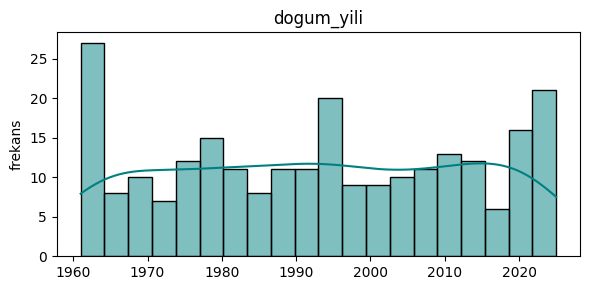

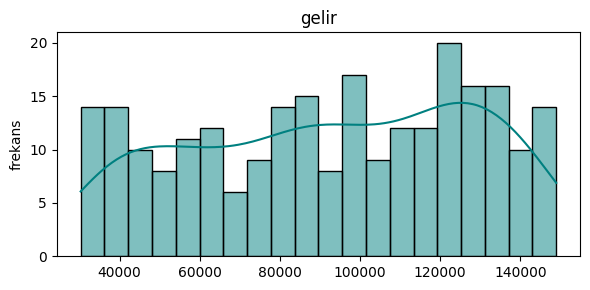

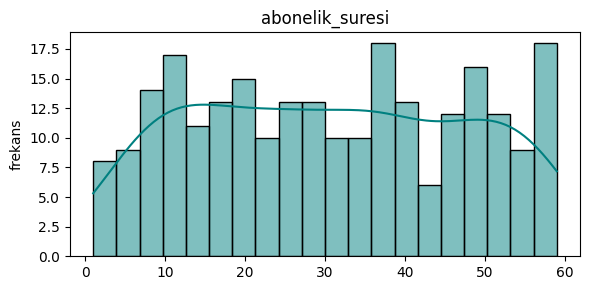

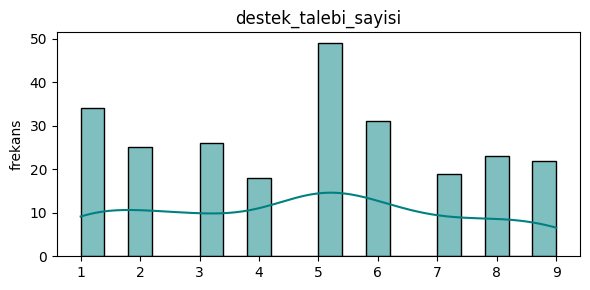

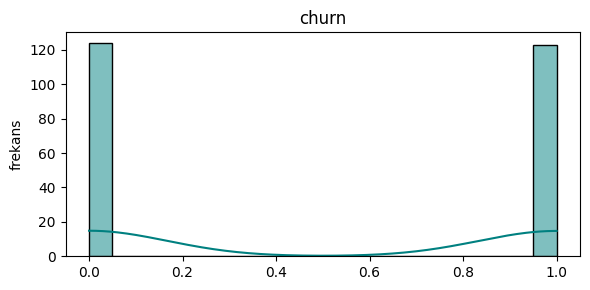

In [39]:
# --- 1. SAYISAL SÜTUNLAR İÇİN SEABORN HİSTOGRAM GRAFİKLERİ ---
for sutun in sayisal_sutunlar:
    if sutun in df1.columns:
        plt.figure(figsize=(6, 3))

        sns.histplot(df1[sutun], bins=20, color="teal", kde=True)
        
        plt.title(f"{sutun}")
        plt.xlabel("")
        plt.ylabel("frekans")
        plt.tight_layout()
        plt.show()


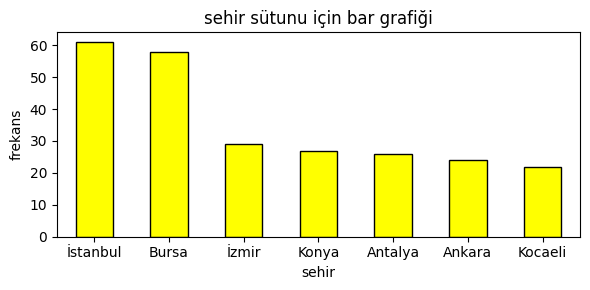

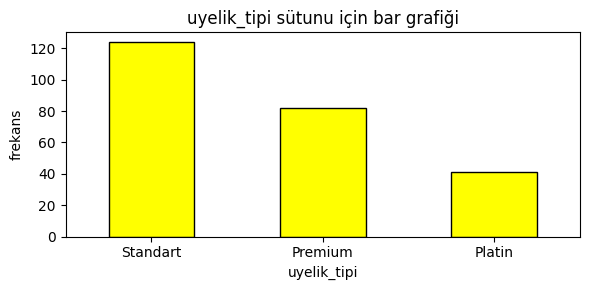

In [40]:
# --- 2. KATEGORİK SÜTUNLAR İÇİN BAR GRAFİKLERİ ---
for sutun in kategorik_sutunlar:
    if sutun in df1.columns:
        plt.figure(figsize=(6, 3))
        df1[sutun].value_counts().plot(kind="bar", color="yellow", edgecolor="black")  
        plt.title(f"{sutun} sütunu için bar grafiği")
        plt.xlabel(sutun)
        plt.ylabel("frekans")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()


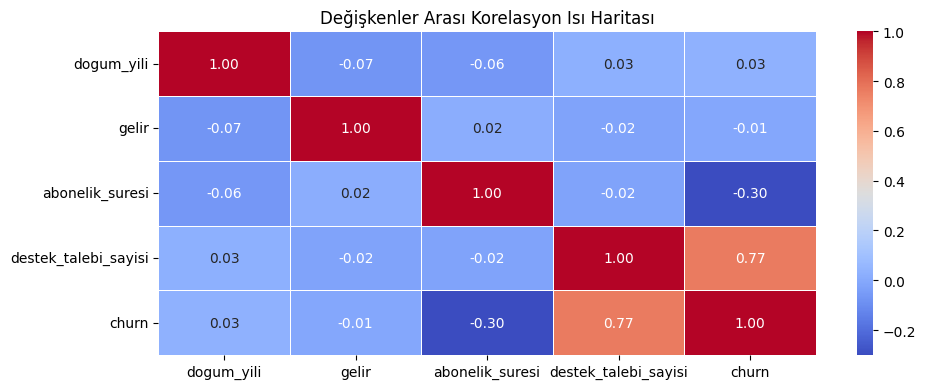

In [41]:
# 18. Korelasyon analizi ile değişkenler arasındaki ilişkilerin incelenmesi
plt.figure(figsize=(10, 4))
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Değişkenler Arası Korelasyon Isı Haritası")
plt.tight_layout()
plt.show()

In [42]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   dogum_yili            247 non-null    int64  
 1   gelir                 247 non-null    float64
 2   abonelik_suresi       247 non-null    int64  
 3   destek_talebi_sayisi  247 non-null    float64
 4   sehir                 247 non-null    object 
 5   uyelik_tipi           247 non-null    object 
 6   churn                 247 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 13.6+ KB


In [43]:
# 19. Bağımlı ve bağımsız değişkenlerin tanımlanması, train/test olarak ayrılması

In [44]:
X = df1.drop("churn", axis=1)  # features
y = df1["churn"]   # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [45]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((197, 6), (50, 6), (197,), (50,))

In [46]:
# 20. Kategorik değişkenleri uygun encoding yöntemlerini uygula

# Encoder nesnelerini saklayacağımız sözlük 
encoders = {}

# Orijinal verileri korumak ve güvenle değiştirmek için kopyalar alıyoruz
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

for col in ["sehir", "uyelik_tipi"]:
    # Her sütun için bağımsız bir encoder oluşturup sözlüğe kaydediyoruz
    encoders[col] = OneHotEncoder(drop="first", sparse_output=False, dtype=int)
    
    # 2. Dönüşüm adımlarını (train_encoded ve test_encoded) doğru matris isimleriyle tanımlıyoruz
    train_encoded = encoders[col].fit_transform(X_train[[col]]) 
    test_encoded = encoders[col].transform(X_test[[col]])
    
    # 3. Yeni oluşan 0-1 sütun isimlerini çıkartıyoruz
    feat_names = encoders[col].get_feature_names_out([col])
    
    # 4. Çıkan sıfır-bir matrislerini yeni sütun adlarıyla DataFrame kopyalarımıza enjekte ediyoruz
    X_train_encoded[feat_names] = train_encoded
    X_test_encoded[feat_names] = test_encoded
    
    # 5. İşlemi biten eski metin tabanlı (object) sütunları tablolardan temizliyoruz
    X_train_encoded.drop(columns=[col], inplace=True)
    X_test_encoded.drop(columns=[col], inplace=True)


In [47]:
X_train_encoded

,dogum_yili,gelir,abonelik_suresi,destek_talebi_sayisi,sehir_Antalya,sehir_Bursa,sehir_Kocaeli,sehir_Konya,sehir_İstanbul,sehir_İzmir,uyelik_tipi_Premium,uyelik_tipi_Standart
145,1972,75543.0,13,6.0,0,0,0,0,1,0,1,0
192,1972,70158.0,54,6.0,0,0,0,0,0,1,0,0
143,2022,35237.0,39,9.0,0,0,0,1,0,0,1,0
234,1988,116027.0,35,1.0,0,0,0,0,0,0,1,0
182,2010,86573.0,18,3.0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
18,2009,131279.0,36,7.0,0,0,0,0,1,0,1,0
113,1989,103523.0,50,1.0,0,0,0,0,0,1,0,1
62,1975,119912.0,28,2.0,0,0,0,0,0,0,0,1
92,2022,125285.0,5,5.0,0,0,0,0,1,0,0,1


In [48]:
# 21. Değişkenlerin ölçeklendirilmesi (StandardScaler)

# Ölçeklendireceğimiz GERÇEK sayısal sütunların listesi
gercek_sayisallar = ['dogum_yili', 'gelir', 'abonelik_suresi', 'destek_talebi_sayisi']

# StandardScaler nesnemizi hazırlıyoruz
scaler = StandardScaler()

# Orijinal tablolara zarar vermemek için kopyalarını oluşturuyoruz
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

# Sadece belirlediğimiz gerçek sayısal sütunları ölçeklendiriyoruz
# Train setinde öğrenip uyguluyor (fit_transform), Test setinde ise sadece uyguluyoruz (transform)
X_train_scaled[gercek_sayisallar] = scaler.fit_transform(X_train_encoded[gercek_sayisallar])
X_test_scaled[gercek_sayisallar] = scaler.transform(X_test_encoded[gercek_sayisallar])

# Modelleme aşamasında kullanacağımız nihai değişken isimlerine atıyoruz
X_train_ = X_train_scaled
X_test_ = X_test_scaled

In [49]:
X_train_

,dogum_yili,gelir,abonelik_suresi,destek_talebi_sayisi,sehir_Antalya,sehir_Bursa,sehir_Kocaeli,sehir_Konya,sehir_İstanbul,sehir_İzmir,uyelik_tipi_Premium,uyelik_tipi_Standart
145,-1.044803,-0.569027,-1.039546,0.495904,0,0,0,0,1,0,1,0
192,-1.044803,-0.724413,1.422023,0.495904,0,0,0,0,0,1,0,0
143,1.440420,-1.732072,0.521449,1.682460,0,0,0,1,0,0,1,0
234,-0.249531,0.599155,0.281296,-1.481689,0,0,0,0,0,0,1,0
182,0.843966,-0.250752,-0.739354,-0.690652,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
18,0.794262,1.039257,0.341334,0.891423,0,0,0,0,1,0,1,0
113,-0.199827,0.238347,1.181870,-1.481689,0,0,0,0,0,1,0,1
62,-0.895689,0.711258,-0.138972,-1.086170,0,0,0,0,0,0,0,1
92,1.440420,0.866298,-1.519852,0.100385,0,0,0,0,1,0,0,1


In [50]:
X_train_.isnull().sum()

dogum_yili              0
gelir                   0
abonelik_suresi         0
destek_talebi_sayisi    0
sehir_Antalya           0
sehir_Bursa             0
sehir_Kocaeli           0
sehir_Konya             0
sehir_İstanbul          0
sehir_İzmir             0
uyelik_tipi_Premium     0
uyelik_tipi_Standart    0
dtype: int64

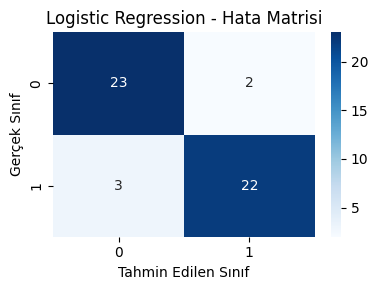

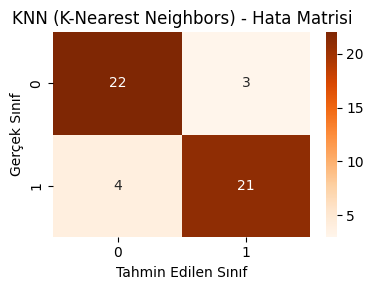

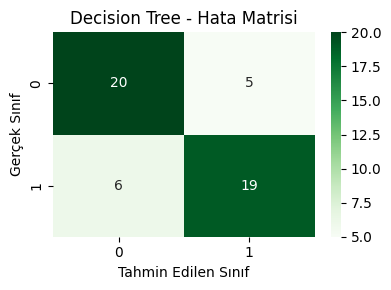

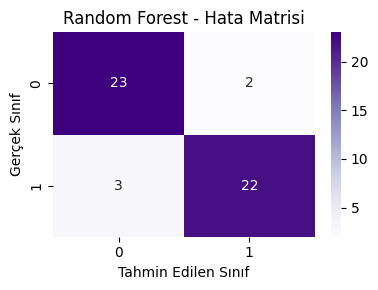

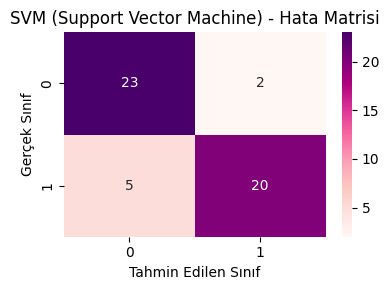


MODELLERİN KARŞILAŞTIRMA TABLOSU


,Model,Accuracy (Doğruluk),Precision (Keskinlik),Recall (Duyarlılık),F1-Score
0,Logistic Regression,90.00,91.67,88.00,89.80
1,KNN (K-Nearest Neighbors),86.00,87.50,84.00,85.71
2,Decision Tree,78.00,79.17,76.00,77.55
3,Random Forest,90.00,91.67,88.00,89.80
4,SVM (Support Vector Machine),86.00,90.91,80.00,85.11


In [51]:
# 22. Tüm Modellerin For Döngüsü ile Eğitilmesi ve Karşılaştırılması

#  1. Modellerimizi bir sözlük (dictionary) içinde tanımlıyoruz
modeller = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "KNN (K-Nearest Neighbors)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    "SVM (Support Vector Machine)": SVC(kernel='rbf', random_state=42)
}
cmap_listesi = ["Blues", "Oranges", "Greens", "Purples", "RdPu"]
# Sonuçları kaydetmek için boş bir liste oluşturuyoruz
sonuclar = []

# 2. For döngüsü ile tüm modelleri sırayla eğitiyoruz
for i, (model_adi, model) in enumerate(modeller.items()):
    # Modeli eğitiyoruz
    model.fit(X_train_, y_train)
    
    # Test seti tahminlerini alıyoruz
    y_pred = model.predict(X_test_)
    
    # Metrikleri hesaplıyoruz (Müşteri Churn=1 sınıfına odaklanıyoruz)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    
    # Sonuçları listeye ekliyoruz
    sonuclar.append({
        "Model": model_adi,
        "Accuracy (Doğruluk)": f"{acc*100:.2f}",
        "Precision (Keskinlik)": f"{prec*100:.2f}",
        "Recall (Duyarlılık)": f"{rec*100:.2f}",
        "F1-Score": f"{f1*100:.2f}"
    })
    
    # Her model için ekrana basit bir Hata Matrisi çiziyoruz
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap= cmap_listesi[i], 
                xticklabels=["0", "1"], yticklabels=["0", "1"])
    plt.title(f"{model_adi} - Hata Matrisi")
    plt.ylabel("Gerçek Sınıf")
    plt.xlabel("Tahmin Edilen Sınıf")
    plt.tight_layout()
    plt.show()

# 3. Tüm sonuçları bir Pandas DataFrame tablosuna dönüştürüp ekrana basıyoruz
sonuclar_df = pd.DataFrame(sonuclar)
print("\n" + "="*60)
print("MODELLERİN KARŞILAŞTIRMA TABLOSU")
print("="*60)
display(sonuclar_df)


In [52]:
# 23. GridSearchCV ile Hiperparametre Optimizasyonu

param_grids = {
    "Logistic Regression": {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs']
    },
    "KNN (K-Nearest Neighbors)": {
        'n_neighbors': [1, 3, 5, 7],
        'weights': ['uniform', 'distance']
    },
    "Decision Tree": {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2,5,10],
        'criterion': ['gini', 'entropy']
    },
    "Random Forest": {
        'n_estimators': [50,100,200],
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10]
    },
    "SVM (Support Vector Machine)": {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto'],
        'kernel': ['rbf', 'linear']
    }
}

tuned_sonuclar = []
en_iyi_modeller = {} # Optimize edilmiş nihai modelleri saklamak için



for model_adi, model_nesnesi in modeller.items():
    
    # İlgili modelin parametre havuzunu çekiyoruz
    grid_havuzu = param_grids[model_adi]
    
    # 5 Katlı Çapraz Doğrulama (CV) ile GridSearchCV nesnesini kuruyoruz
    grid_search = GridSearchCV(
        estimator=model_nesnesi, 
        param_grid=grid_havuzu, 
        cv=5, 
        scoring='accuracy', 
        n_jobs=-1
    )
    
    # Modeli eğitiyoruz (En iyi parametreleri buluyor)
    grid_search.fit(X_train_, y_train)
    
    # En başarılı parametre kombinasyonuna sahip modeli seçiyoruz
    best_model = grid_search.best_estimator_
    en_iyi_modeller[model_adi] = best_model
    
    # Test seti üzerinde en iyi modelle tahmin gerçekleştiriyoruz
    y_pred_tuned = best_model.predict(X_test_)
    
    # Metrikleri hesaplıyoruz
    acc = accuracy_score(y_test, y_pred_tuned)
    prec = precision_score(y_test, y_pred_tuned, pos_label=1)
    rec = recall_score(y_test, y_pred_tuned, pos_label=1)
    f1 = f1_score(y_test, y_pred_tuned, pos_label=1)
    
    # Sonuçları listeye kaydediyoruz
    tuned_sonuclar.append({
        "Model": model_adi,
        "En İyi Parametreler": str(grid_search.best_params_),
        "Tuned Accuracy": f"%{acc*100:.2f}",
        "Tuned Precision": f"%{prec*100:.2f}",
        "Tuned Recall": f"%{rec*100:.2f}",
        "Tuned F1-Score": f"%{f1*100:.2f}"
    })

#  Tüm optimize sonuçları bir Pandas DataFrame tablosuna dönüştürüyoruz.
tuned_sonuclar_df = pd.DataFrame(tuned_sonuclar)
print("\n" + "="*80)
print("HİPERPARAMETRE OPTİMİZASYONU SONRASI NİHAİ MODEL BAŞARI TABLOSU")
print("="*80)
display(tuned_sonuclar_df)


HİPERPARAMETRE OPTİMİZASYONU SONRASI NİHAİ MODEL BAŞARI TABLOSU


,Model,En İyi Parametreler,Tuned Accuracy,Tuned Precision,Tuned Recall,Tuned F1-Score
0,Logistic Regression,"{'C': 0.01, 'solver': 'lbfgs'}",%90.00,%95.45,%84.00,%89.36
1,KNN (K-Nearest Neighbors),"{'n_neighbors': 7, 'weights': 'distance'}",%90.00,%91.67,%88.00,%89.80
2,Decision Tree,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",%88.00,%91.30,%84.00,%87.50
3,Random Forest,"{'max_depth': None, 'min_samples_split': 2, 'n...",%88.00,%88.00,%88.00,%88.00
4,SVM (Support Vector Machine),"{'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}",%86.00,%90.91,%80.00,%85.11


In [53]:
# En iyi Random Forest modelinin öznitelik önem derecelerini alalım
onem_dereceleri = en_iyi_modeller["Random Forest"].feature_importances_
sutun_isimleri = X_train_.columns


df_onem = pd.DataFrame({
    'Öznitelik': sutun_isimleri,
    'Önem Skoru': onem_dereceleri
}).sort_values(by='Önem Skoru', ascending=False).reset_index(drop=True)


display(df_onem.round(4))

,Öznitelik,Önem Skoru
0,destek_talebi_sayisi,0.5118
1,abonelik_suresi,0.2004
2,gelir,0.1130
3,dogum_yili,0.0805
4,uyelik_tipi_Premium,0.0159
5,sehir_Bursa,0.0145
6,uyelik_tipi_Standart,0.0143
7,sehir_İstanbul,0.0131
8,sehir_Kocaeli,0.0104
9,sehir_İzmir,0.0099
